# Xora: smarter delivery planning for Waypoint Group

Waypoint Group delivers for three retail brands from two depots. Every evening a dispatcher drafts the next day's routes, and too often the plan is wrong: trucks reach stores after their windows close, festival weeks catch the fleet short, and on a bad day there are more orders than trucks. This notebook is our full answer, from the raw files to the decisions people make with it.

### Results at a glance

| Question | Waypoint today | Our approach | Result on data the models never saw |
|---|---|---|---|
| **Task 1.** How long will each delivery take? | published allowance table, off by 7.1 min a stop | LightGBM on cutoff-time features | **3.9 min** error a stop, **45% less** |
| **Task 1.** Will the truck arrive after the window closes? | slack on paper (log loss 0.287, AUC 0.86) | 1,000 replays of every route, blended with a direct classifier | **log loss 0.136, AUC 0.97**, calibrated |
| **Task 2A.** How much volume in the next 10 weeks? | same week last year | daily festival-aware models added up into ISO weeks | **5.2% error** on total, **3.6%** on chilled; **41 to 54% less error** than last year's pattern |
| **Task 2B.** Who gets served on a peak day? | dispatcher judgement | optimiser with a fixed, agreed order of priorities | **76 of 85 orders**, every repeat deferral served, chilled volume **within 0.2% of the proven maximum**, passes Waypoint's checker |
| **People.** What should each person do? | probabilities nobody reads | traffic lights, clock times and one-line reasons | the red stops are **21% of stops** but carry **over 80%** of expected late arrivals |

Part 11 recomputes every number in this table from the saved models and outputs.

### How this notebook is organised

It follows CRISP-DM, the standard industry process for data science projects. Every part starts with its purpose and ends with a short summary, so it can be read top to bottom or one part at a time.

| CRISP-DM phase | Part |
|---|---|
| Business understanding | 1. The problem and the solution at a glance |
| Data understanding | 2. Data understanding |
| Data preparation | 3. Data quality and cleaning; 4. Label construction; 5. Feature engineering |
| Modelling and evaluation | 6. Task 1: service time and late risk; 7. Task 2A: demand forecast; 8. Task 2B: peak-day allocation |
| Deployment | 9. The decision layer; 10. Deployment, impact and limits; 11. Reload the saved models and run inference |

**To run it:** follow the README to install the pinned requirements and unzip the data into `data/raw/`, then run all cells. A full run rebuilds every table, model and submission from the raw files and takes about an hour on a laptop, most of it in the Task 1 models and the Task 2B optimiser. Seeds are fixed, so results reproduce. The one exception is the last kilometre step of the Task 2B optimiser, which stops on a time limit and so can settle on a slightly different but equally valid route plan on a slower or faster machine.

In [1]:
import json
import subprocess
import sys
import warnings

import joblib
import lightgbm as lgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score

from xora import allocation as al
from xora import checks as ck
from xora import decisions as dl
from xora import features as fe
from xora import forecast as fc
from xora.io import load_processed, load_raw, save_processed
from xora.paths import DATA_RAW, MODELS, REPO_ROOT, REPORTS, SUBMISSIONS, raw_file
from xora.plotting import apply_style, SERIES, INK, INK_SOFT
from xora.simulation import LGB_PARAMS, SEED, TRAVEL_FEATURES, DELAY_FEATURES, RouteSimulator, _fit_lgb
from xora.timeutils import hhmm_to_minutes

warnings.filterwarnings("ignore", category=UserWarning)
apply_style()
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 110)

## Part 1. The problem and the solution at a glance

**The business.** Waypoint Group runs 60 vehicles from a distribution centre in Peliyagoda and a regional hub in Kandy, serving 120 outlets for three brands:
- **Fresh**, 80 supermarkets that must be stocked before they open at 8 AM, with chilled goods that only refrigerated trucks (reefers) can carry
- **Style**, 25 fashion stores, many in malls with fixed delivery windows
- **Tech**, 15 electronics stores with heavy, fragile, high-value orders

**Three questions, three decisions.**

| Task | Question | Decision it feeds | Who decides |
|---|---|---|---|
| 1 | How long will each stop take, and will the truck be late? | which routes to change before the trucks leave | dispatcher, driver |
| 2A | How much total and chilled volume will each depot and brand need over the next 10 weeks? | how many trucks and reefers to have ready, and when to service them | fleet manager |
| 2B | On a peak day with vehicles in the workshop, which orders ride on which truck, and which wait? | the day's allocation and what to tell each store | dispatcher |

**What made it hard, and how we handled it.**
- **Waiting is not working.** A truck that arrives before a store opens waits outside. Service time has to start at the later of arrival and window opening, or the labels are wrong (Part 4).
- **Lateness builds up along a route.** One slow stop delays every stop after it, so Task 1 replays whole routes instead of scoring stops one by one (Part 6).
- **Festivals move.** Vesak fell in ISO week 21, then 20, and is week 18 in 2026. Any method that copies last year's weeks puts the spike in the wrong place, so Task 2A forecasts days and adds them up into weeks (Part 7).
- **Some orders cannot ride at all.** One Task 2B order is bigger than any truck, and chilled demand is far above what the remaining reefers can carry, so the plan has to prove which deferrals are forced and price the ones that are choices (Part 8).
- **Nothing leaks from the future.** Every feature is something a planner knows at the 4 PM cutoff, and Part 5 proves it.

**The solution end to end.** The diagram is drawn from the pipeline itself and saved to `docs/figures/` for reuse.

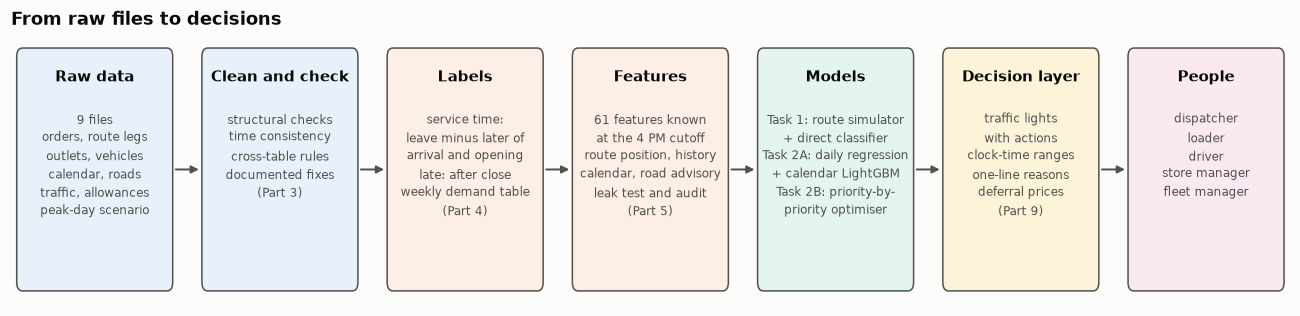

In [2]:
def box(ax, x, y, w, h, title, lines, color):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.08",
                                facecolor=color, edgecolor=INK_SOFT, linewidth=1))
    ax.text(x + w / 2, y + h - 0.18, title, ha="center", va="top", fontsize=10, fontweight="bold", color=INK)
    ax.text(x + w / 2, y + h - 0.55, "\n".join(lines), ha="center", va="top", fontsize=8, color=INK_SOFT, linespacing=1.5)

def arrow(ax, x0, y0, x1, y1):
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0), arrowprops=dict(arrowstyle="-|>", color=INK_SOFT, lw=1.3))

def flow(columns, height=2.2, figsize=(15, 3.2), title=None, loop=None):
    fig, ax = plt.subplots(figsize=figsize)
    w, gap = 2.15, 0.45
    for i, (head, items, color) in enumerate(columns):
        x = i * (w + gap)
        box(ax, x, 0, w, height, head, items, color)
        if i:
            arrow(ax, x - gap + 0.02, height / 2, x - 0.02, height / 2)
    bottom = -0.15
    if loop:
        # A feedback arrow under the boxes, from one column back to an earlier one
        src, dst, label = loop
        xs, xd = src * (w + gap) + w / 2, dst * (w + gap) + w / 2
        ax.annotate("", xy=(xd, -0.05), xytext=(xs, -0.05),
                    arrowprops=dict(arrowstyle="-|>", color=INK_SOFT, lw=1.3, connectionstyle="bar,fraction=-0.06"))
        ax.text((xs + xd) / 2, -0.5, label, ha="center", va="center", fontsize=8.5, color=INK_SOFT)
        bottom = -0.75
    ax.set_xlim(-0.1, len(columns) * (w + gap) - gap + 0.1)
    ax.set_ylim(bottom, height + 0.15)
    ax.axis("off")
    if title:
        ax.set_title(title, loc="left")
    return fig

LIGHT = ["#e8f0fb", "#fdeee6", "#e3f5ee", "#fdf3d9", "#fbe9f1", "#e6f2e6"]
pipeline = flow([
    ("Raw data", ["9 files", "orders, route legs", "outlets, vehicles", "calendar, roads", "traffic, allowances", "peak-day scenario"], LIGHT[0]),
    ("Clean and check", ["structural checks", "time consistency", "cross-table rules", "documented fixes", "(Part 3)"], LIGHT[0]),
    ("Labels", ["service time:", "leave minus later of", "arrival and opening", "late: after close", "weekly demand table", "(Part 4)"], LIGHT[1]),
    ("Features", ["61 features known", "at the 4 PM cutoff", "route position, history", "calendar, road advisory", "leak test and audit", "(Part 5)"], LIGHT[1]),
    ("Models", ["Task 1: route simulator", "+ direct classifier", "Task 2A: daily regression", "+ calendar LightGBM", "Task 2B: priority-by-", "priority optimiser"], LIGHT[2]),
    ("Decision layer", ["traffic lights", "with actions", "clock-time ranges", "one-line reasons", "deferral prices", "(Part 9)"], LIGHT[3]),
    ("People", ["dispatcher", "loader", "driver", "store manager", "fleet manager"], LIGHT[4]),
], title="From raw files to decisions")
(REPO_ROOT / "docs" / "figures").mkdir(parents=True, exist_ok=True)
pipeline.savefig(REPO_ROOT / "docs" / "figures" / "architecture_pipeline.png", dpi=160, bbox_inches="tight")
plt.show()

## Part 2. Data understanding

**Purpose:** get to know every file before changing anything. This part only reads and describes the data. Cleaning happens in Part 3, and labels are built in Part 4.

**Inputs:** the raw data files in `data/raw/`.

**Outputs:** none. The findings here shape the decisions in the later parts, and they are summarised at the end.

**Questions this part answers**
1. What is in each file, and how do the files connect?
2. What does the delivery network look like (outlets, vehicles, depots)?
3. How do orders and route legs relate, and what period do train and test cover?
4. How often are deliveries late, and what seems to drive it?
5. How does weekly demand move, especially around festivals?
6. How tight is the Task 2B peak day?

### 2.1 File inventory

The data zip has four folders. Here is every CSV with its size and shape.

In [3]:
inventory = []
for path in sorted(DATA_RAW.rglob("*.csv")):
    df = pd.read_csv(path)
    inventory.append({
        "folder": path.parent.name,
        "file": path.name,
        "rows": len(df),
        "columns": df.shape[1],
    })
pd.DataFrame(inventory)

,folder,file,rows,columns
0,General Data,calendar.csv,910,12
1,General Data,district_travel.csv,12,8
2,General Data,outlets.csv,120,9
3,General Data,road_conditions.csv,10920,3
4,General Data,service_allowance.csv,9,3
5,General Data,traffic_speed.csv,576,4
6,General Data,vehicles.csv,60,9
7,Submission Templates,submission_task1.csv,5014,3
8,Submission Templates,submission_task2a.csv,60,3
9,Submission Templates,submission_task2b.csv,85,6


In [4]:
orders = load_raw("deliveries_train.csv")
legs = load_raw("route_legs_train.csv")
orders_test = load_raw("task1_test_inputs.csv")
legs_test = load_raw("route_legs_test.csv")
outlets = load_raw("outlets.csv")
vehicles = load_raw("vehicles.csv")
calendar = load_raw("calendar.csv")
district_travel = load_raw("district_travel.csv")
allowance = load_raw("service_allowance.csv")
road = load_raw("road_conditions.csv")
traffic = load_raw("traffic_speed.csv")

**How the files connect**

- `deliveries_train.csv` has one row per order. Each dispatched order points to a route (`route_id`) and its position on that route (`seq_in_route`).
- `route_legs_train.csv` has one row per leg: a drive from the depot or the previous stop to the next outlet. It holds the actual times we need for labels.
- `outlets.csv`, `vehicles.csv`, `district_travel.csv` and `service_allowance.csv` describe the network and the current planning standards.
- `calendar.csv`, `road_conditions.csv` and `traffic_speed.csv` describe each day: paydays, festivals, monsoon, road disruption and traffic speed by hour.
- The test files mirror the train files but only carry planned times.

### 2.2 The delivery network

Three brands share one fleet. By design, Fresh delivers daily before 8 AM, Style weekly with seasonal peaks, and Tech as needed.

In [5]:
outlet_mix = outlets.pivot_table(index="brand", columns="depot", values="outlet_id", aggfunc="count", margins=True, margins_name="total")
outlet_mix

depot,Kandy,Peliyagoda,total
brand,,,
Fresh,31,49,80
Style,9,16,25
Tech,5,10,15
total,45,75,120


In [6]:
# Access constraints matter for both service time and Task 2B
pd.crosstab([outlets.brand, outlets.dock_type], outlets.parking_constraint)

parking_constraint  mall_dock  normal  van_only
brand dock_type                                
Fresh rear_dock             0      55         0
      street                0      14        11
Style mall_bay              9       0         0
      rear_dock             0       6         0
      street                0       9         1
Tech  mall_bay              3       0         0
      rear_dock             0       7         0
      street                0       4         1

In [7]:
fleet = vehicles.groupby(["depot", "type", "temp"]).agg(
    vehicles=("vehicle_id", "count"),
    volume_m3=("volume_cap_m3", "sum"),
    weight_kg=("weight_cap_kg", "sum"),
)
fleet

vehicles  volume_m3  weight_kg
depot      type  temp                                   
Kandy      truck ambient        13      362.0      66000
                 reefer          5      132.0      26990
           van   ambient         2       18.0       2400
                 reefer          2       14.0       2080
Peliyagoda truck ambient        27      788.0     145200
                 reefer          7      193.5      39140
           van   ambient         2       17.0       2300
                 reefer          2       14.0       2080

In [8]:
district_travel.merge(
    outlets.groupby("district").size().rename("outlets"), left_on="district", right_index=True
)[["district", "depot", "road_class", "outlets", "depot_to_district_km", "depot_to_district_freeflow_min", "inter_stop_freeflow_min"]]

,district,depot,road_class,outlets,depot_to_district_km,depot_to_district_freeflow_min,inter_stop_freeflow_min
0,Colombo,Peliyagoda,urban,24,12,24,8
1,Gampaha,Peliyagoda,suburban,15,28,37,9
2,Kalutara,Peliyagoda,suburban,10,48,64,12
3,Galle,Peliyagoda,highway,9,120,103,9
4,Matara,Peliyagoda,highway,6,160,137,10
5,Kurunegala,Peliyagoda,suburban,8,95,127,19
6,Puttalam,Peliyagoda,suburban,3,130,173,24
7,Kandy,Kandy,urban,20,8,16,6
8,Matale,Kandy,suburban,8,26,35,11
9,Nuwara Eliya,Kandy,hill,6,78,111,20


**What stands out**

- Fresh is two thirds of the outlets, so it will dominate both labels and demand.
- Only 16 of 60 vehicles can carry chilled goods, which hints that refrigeration is the scarce resource.
- Some districts are far from their depot (Puttalam is 173 free-flow minutes from Peliyagoda). Before 8 AM that leaves little room for more than one trip.

### 2.3 Orders and route legs

First, what period each set covers and what happened to each order.

In [9]:
period = pd.DataFrame({
    "first order": [orders.order_date.min(), orders_test.order_date.min()],
    "last order": [orders.order_date.max(), orders_test.order_date.max()],
    "orders": [len(orders), len(orders_test)],
    "route legs": [len(legs), len(legs_test)],
}, index=["train", "test"])
period

,first order,last order,orders,route legs
train,2024-01-01,2026-02-14,92307,91894
test,2026-02-16,2026-03-28,5014,5014


In [10]:
status = pd.concat({
    "train": orders.dispatch_status.value_counts(),
    "test": orders_test.dispatch_status.value_counts(),
}, axis=1).fillna(0).astype(int)
status

,train,test
dispatch_status,,
attempted,90351,4924
deferred,1543,90
not_run,413,0


In [11]:
pd.crosstab(orders.brand, orders.temp_requirement, margins=True)

temp_requirement,ambient,chilled,All
brand,,,
Fresh,52720,35135,87855
Style,2740,0,2740
Tech,1712,0,1712
All,57172,35135,92307


`attempted` orders went out on their order date. `deferred` orders were pushed to the next day. `not_run` orders were never dispatched, so they have no route. The test set has no `not_run` orders, which matters later for the Task 2A weekly totals.

Next, does every dispatched order have exactly one leg? We join on route and stop position.

In [12]:
dispatched = orders[orders.route_id.notna()].astype({"seq_in_route": int})
joined = dispatched.merge(
    legs, left_on=["route_id", "seq_in_route"], right_on=["route_id", "seq"],
    how="left", suffixes=("", "_leg"), indicator=True,
)
pd.Series({
    "dispatched orders": len(dispatched),
    "matched to a leg": (joined._merge == "both").sum(),
    "outlet agrees": (joined.outlet_id == joined.to_outlet).sum(),
    "leg date equals dispatch date": (joined.dispatch_date == joined.date).sum(),
})

dispatched orders                91894
matched to a leg                 91894
outlet agrees                    91894
leg date equals dispatch date    91894
dtype: int64

Every dispatched order, including deferred ones, matches exactly one leg, and the outlet and date agree in every case. So the leg is where each order's actual arrival and departure times live, and deferred orders can be used for training too.

Most Fresh outlets get two orders on the same day: one ambient and one chilled. They usually travel on different vehicles.

In [13]:
orders.groupby(["order_date", "outlet_id"]).size().value_counts().rename("outlet-days").rename_axis("orders per outlet per day")

orders per outlet per day
2    35135
1    22037
Name: outlet-days, dtype: int64

### 2.4 Lateness and timing: a first look

The formal labels come in Part 4. Here we use the raw times to see the shape of the problem. An arrival counts as late when it is after the outlet's `window_close_time`.

In [14]:
j = joined.copy()
for col in ["planned_arrival_time", "arrival_time", "window_close_time", "planned_depart_time", "actual_depart_time"]:
    j[col + "_min"] = hhmm_to_minutes(j[col])

j["late"] = j.arrival_time_min > j.window_close_time_min
j["arrival_vs_plan_min"] = j.arrival_time_min - j.planned_arrival_time_min

pd.Series({
    "late rate": j.late.mean().round(3),
    "median minutes later than planned": j.arrival_vs_plan_min.median(),
    "mean minutes later than planned": j.arrival_vs_plan_min.mean().round(1),
    "Fresh arriving after 08:00": (j.loc[j.brand == "Fresh", "arrival_time_min"] > 480).mean().round(3),
})

late rate                             0.196
median minutes later than planned    35.000
mean minutes later than planned      52.600
Fresh arriving after 08:00            0.193
dtype: float64

In [15]:
j.groupby("brand").late.mean().round(3).rename("late rate").to_frame()

,late rate
brand,
Fresh,0.204
Style,0.055
Tech,0.025


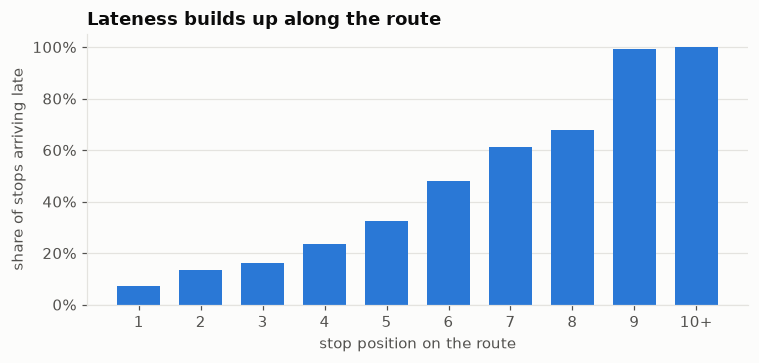

stop,1,2,3,4,5,6,7,8,9,10
mean,0.072,0.135,0.162,0.234,0.323,0.48,0.612,0.678,0.991,1.0
size,25198.000,21371.000,16222.000,12120.000,7464.000,5296.00,2527.000,1110.000,452.000,134.0


In [16]:
by_stop = j.assign(stop=(j.seq + 1).clip(upper=10)).groupby("stop").late.agg(["mean", "size"])

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.bar(by_stop.index, by_stop["mean"], color=SERIES[0], width=0.7)
ax.set_xticks(by_stop.index, [str(i) if i < 10 else "10+" for i in by_stop.index])
ax.set_xlabel("stop position on the route")
ax.set_ylabel("share of stops arriving late")
ax.set_title("Lateness builds up along the route")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
plt.tight_layout()
plt.show()
by_stop.round(3).T

Lateness is cumulative: every delay at an earlier stop pushes back the later ones. This is the main reason Task 1 will simulate whole routes instead of scoring each stop in isolation.

What slows the trucks down? We compare actual with planned travel time, against monsoon and the daily road disruption index (100 means clear roads).

In [17]:
j = j.merge(road, on=["district", "date"], how="left")
j["travel_ratio"] = j.actual_travel_duration_min / j.planned_travel_duration_min.clip(lower=1)
j["disruption_band"] = pd.cut(j.disruption_index, [0, 60, 80, 95, 100], labels=["below 60", "60 to 80", "80 to 95", "95 to 100"])

pd.concat({
    "by monsoon": j.groupby("monsoon").travel_ratio.median(),
    "by road disruption": j.groupby("disruption_band", observed=True).travel_ratio.median(),
}).round(2).rename("median actual / planned travel").to_frame()

median actual / planned travel
by monsoon         0                                    1.36
                   1                                    1.73
by road disruption below 60                             2.95
                   60 to 80                             2.10
                   80 to 95                             1.60
                   95 to 100                            1.40

In [18]:
first_stop = j[j.seq == 0]
(first_stop.actual_depart_time_min - first_stop.planned_depart_time_min).describe().round(1).rename("depot departure delay (min)").to_frame().T

,count,mean,std,min,25%,50%,75%,max
depot departure delay (min),25198.0,7.7,6.0,0.0,4.0,6.0,10.0,63.0


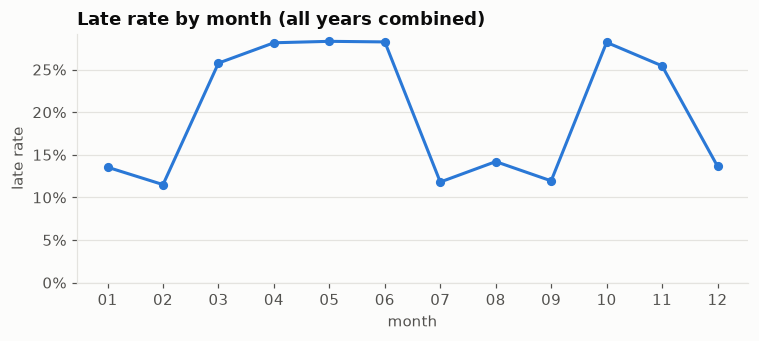

In [19]:
monthly = j.assign(month=j.date.str[5:7]).groupby("month").late.mean()

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(monthly.index, monthly.values, color=SERIES[0], marker="o", markersize=5)
ax.set_ylim(0, None)
ax.set_xlabel("month")
ax.set_ylabel("late rate")
ax.set_title("Late rate by month (all years combined)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
plt.tight_layout()
plt.show()

**What stands out**

- Trucks arrive well after their planned times, so today's plans are optimistic.
- Travel slows sharply in the monsoon and on disrupted days, and the trucks leave the depot late too.
- Late rates roughly double in the monsoon and festival months.

`road_conditions.csv` covers the test period as well, so disruption can be used as a feature. Part 5 checks whether a planner would actually know it at the 4 PM cutoff.

### 2.5 Demand over time

Task 2A asks for weekly volume per depot and brand, using ISO weeks from the calendar and counting every order on its order date. The test inputs for Task 1 fill the gap between the end of training and the forecast weeks, so we stack both here.

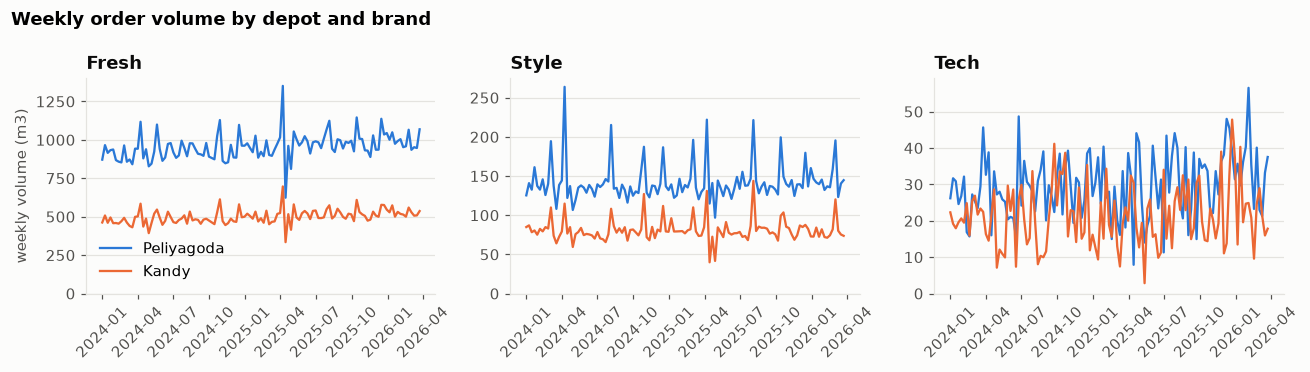

In [20]:
all_orders = pd.concat([orders.assign(source="train"), orders_test.assign(source="test")], ignore_index=True)
all_orders = all_orders.merge(calendar[["date", "iso_year", "iso_week"]], left_on="order_date", right_on="date")

weekly = all_orders.groupby(["depot", "brand", "iso_year", "iso_week"]).order_volume_m3.sum().reset_index()
weekly["week_start"] = pd.to_datetime(weekly.iso_year.astype(str) + "-W" + weekly.iso_week.astype(str).str.zfill(2) + "-1", format="%G-W%V-%u")

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharex=True)
for ax, brand in zip(axes, ["Fresh", "Style", "Tech"]):
    for i, depot in enumerate(["Peliyagoda", "Kandy"]):
        s = weekly[(weekly.brand == brand) & (weekly.depot == depot)]
        ax.plot(s.week_start, s.order_volume_m3, color=SERIES[i], linewidth=1.5, label=depot)
    ax.set_title(brand)
    ax.set_ylim(0, None)
    ax.tick_params(axis="x", rotation=45)
axes[0].set_ylabel("weekly volume (m3)")
axes[0].legend()
fig.suptitle("Weekly order volume by depot and brand", x=0.01, ha="left", fontweight="bold")
plt.tight_layout()
plt.show()

The series are steady with sharp spikes and dips. The calendar shows that festivals sit behind most of them, and that festivals fall in different ISO weeks each year:

In [21]:
festival_weeks = (
    calendar.dropna(subset=["festival"])
    .groupby(["festival", "iso_year"]).iso_week.min()
    .unstack("iso_year")
)
festival_weeks.loc[["new_year", "vesak", "poson"]]

iso_year,2024,2025,2026
festival,,,
new_year,15.0,16.0,16.0
vesak,21.0,20.0,18.0
poson,25.0,24.0,22.0


In [22]:
pf = weekly[(weekly.depot == "Peliyagoda") & (weekly.brand == "Fresh")].pivot(index="iso_week", columns="iso_year", values="order_volume_m3")
operating_days = calendar.groupby(["iso_year", "iso_week"]).is_operating.sum().unstack("iso_year")
pd.concat({"Peliyagoda Fresh volume (m3)": pf.loc[13:24].round(0), "operating days": operating_days.loc[13:24]}, axis=1)

Peliyagoda Fresh volume (m3)                 operating days          
iso_year                         2024    2025    2026           2024 2025 2026
iso_week                                                                      
13                              943.0   975.0  1068.0            6.0  6.0  6.0
14                              942.0  1016.0     NaN            6.0  6.0  6.0
15                             1118.0  1351.0     NaN            5.0  6.0  6.0
16                              879.0   623.0     NaN            6.0  4.0  4.0
17                              939.0   961.0     NaN            6.0  6.0  6.0
18                              828.0   811.0     NaN            5.0  5.0  5.0
19                              845.0  1054.0     NaN            6.0  6.0  6.0
20                              923.0  1005.0     NaN            6.0  6.0  6.0
21                             1099.0   963.0     NaN            6.0  6.0  6.0
22                              941.0   984.0     NaN            6.0  6.0  6.0
23                              863.0  1024.0     NaN            6.0  6.0  6.0
24                              885.0   991.0     NaN            6.0  6.0  6.0

New Year falls in week 15 in 2024 but week 16 in 2025 and 2026. The week before a festival spikes and the festival week itself drops, partly because it has fewer operating days. So a "same week last year" forecast puts the peak in the wrong week. Part 7 handles this by forecasting days with calendar features and then adding them up into weeks.

### 2.6 The Task 2B peak day

Scenario S1 is a festival peak at Peliyagoda with some vehicles in the workshop. Here we only size the problem. Part 8 solves it.

In [23]:
s1 = load_raw("task2b_peak_day_scenarios.csv")
s1_fleet = load_raw("task2b_peak_day_fleet.csv").merge(vehicles, on="vehicle_id")

s1_fleet.groupby(["status", "type", "temp"]).agg(
    vehicles=("vehicle_id", "count"), volume_m3=("volume_cap_m3", "sum")
)

vehicles  volume_m3
status      type  temp                        
available   truck ambient        22      656.0
                  reefer          3       79.2
            van   ambient         2       17.0
                  reefer          1        7.0
in_workshop truck ambient         5      132.0
                  reefer          4      114.3
            van   reefer          1        7.0

In [24]:
available = s1_fleet[s1_fleet.status == "available"]
pd.DataFrame({
    "demand m3": s1.groupby("temp_requirement").order_volume_m3.sum(),
    "capacity per trip m3": [
        available.volume_cap_m3.sum(),                                  # ambient can go on any vehicle
        available.loc[available.temp == "reefer", "volume_cap_m3"].sum(),  # chilled needs a reefer
    ],
}, index=["ambient", "chilled"]).round(1)

,demand m3,capacity per trip m3
ambient,228.2,759.2
chilled,181.6,86.2


In [25]:
largest_vehicle = available.volume_cap_m3.max()
s1.loc[s1.order_volume_m3 > largest_vehicle, ["order_ref", "outlet_id", "brand", "district", "order_volume_m3"]].assign(largest_vehicle_m3=largest_vehicle)

,order_ref,outlet_id,brand,district,order_volume_m3,largest_vehicle_m3
78,S1-078,OUT070,Style,Kurunegala,40.66,38.0


In [26]:
s1[["deferred_yesterday", "days_since_last_served"]].value_counts().sort_index().rename("orders").to_frame()

orders
deferred_yesterday days_since_last_served        
0                  1                           47
                   2                           28
1                  2                            3
                   3                            2
                   5                            5

Ambient capacity is plentiful. Chilled is the bottleneck: chilled demand is roughly double the reefer space available per trip, and far districts can only get one trip before 8 AM. One Style order is bigger than any vehicle, so it cannot be served whatever we do. Some outlets were already deferred yesterday, so fairness has to be part of the policy.

### Part 2 summary

| Finding | Where it is used |
|---|---|
| Every dispatched order joins to exactly one route leg, including deferred ones | Part 4 builds labels from the legs |
| Lateness builds up along the route and depends on depot delay, monsoon and road disruption | Part 6 simulates whole routes |
| Today's planned arrival times are optimistic | The "before" baseline every model must beat |
| Festivals move between ISO weeks, and festival weeks have fewer operating days | Part 7 forecasts days, then sums to weeks |
| Test inputs have no `not_run` orders | Part 4 adjusts the weekly totals for the test weeks |
| On the peak day, refrigeration is the bottleneck and one order is larger than any vehicle | Part 8 |

## Part 3. Data quality and cleaning

**Purpose:** check every table against the rules it should follow, explain anything unusual, and save clean, typed tables for the rest of the project.

**Inputs:** the raw data files in `data/raw/`.

**Outputs** (in `data/processed/`):
- `orders.parquet`: train and test orders in one table, with a `split` column
- `legs.parquet`: train and test route legs in one table
- `outlets.parquet`, `vehicles.parquet`, `calendar.parquet`, `road_conditions.parquet`, `traffic_speed.parquet`, `district_travel.parquet`, `service_allowance.parquet`

**Approach:** every rule is written as a check that reports how many rows break it. One summary table shows everything at once, instead of the checks stopping at the first problem. Nothing is dropped silently: each fix or exclusion is stated with its reason.

In [27]:
orders = load_raw("deliveries_train.csv")
legs = load_raw("route_legs_train.csv")
orders_test = load_raw("task1_test_inputs.csv")
legs_test = load_raw("route_legs_test.csv")
outlets = load_raw("outlets.csv")
vehicles = load_raw("vehicles.csv")
calendar = load_raw("calendar.csv")
road = load_raw("road_conditions.csv")
traffic = load_raw("traffic_speed.csv")
district_travel = load_raw("district_travel.csv")
allowance = load_raw("service_allowance.csv")

### 3.1 Structural checks

Keys must be unique, categories must take only their documented values, and quantities must be positive.

In [28]:
BRANDS = {"Fresh", "Style", "Tech"}
DEPOTS = {"Peliyagoda", "Kandy"}

rows = []
for name, df in [("orders train", orders), ("orders test", orders_test)]:
    rows += [
        ck.unique_key(df, ["delivery_id"], name),
        ck.allowed_values(df, "brand", BRANDS, name),
        ck.allowed_values(df, "depot", DEPOTS, name),
        ck.allowed_values(df, "temp_requirement", {"chilled", "ambient"}, name),
        ck.allowed_values(df, "dispatch_status", {"attempted", "deferred", "not_run"}, name),
        ck.check(f"{name}: units, weight and volume are positive",
                 (df[["order_units", "order_weight_kg", "order_volume_m3"]] <= 0).any(axis=1).sum(), len(df)),
    ]
for name, df in [("legs train", legs), ("legs test", legs_test)]:
    rows += [
        ck.unique_key(df, ["leg_id"], name),
        ck.unique_key(df, ["route_id", "seq"], name),
        ck.in_range(df, "dow", 0, 5, name),
        ck.in_range(df, "monsoon", 0, 1, name),
        ck.check(f"{name}: distance is positive", (df.distance_km <= 0).sum(), len(df)),
    ]
rows += [
    ck.unique_key(outlets, ["outlet_id"], "outlets"),
    ck.unique_key(vehicles, ["vehicle_id"], "vehicles"),
    ck.unique_key(calendar, ["date"], "calendar"),
    ck.unique_key(road, ["district", "date"], "road conditions"),
    ck.check("train and test share no delivery_id", len(set(orders.delivery_id) & set(orders_test.delivery_id)), len(orders_test)),
    ck.check("test and train share no route_id", legs_test.route_id.isin(legs.route_id).sum(), len(legs_test)),
]
ck.report(rows)

,check,passed,failing_rows,total_rows,note
0,orders train: delivery_id is unique,True,0,92307,
1,"orders train: brand in ['Fresh', 'Style', 'Tech']",True,0,92307,
2,"orders train: depot in ['Kandy', 'Peliyagoda']",True,0,92307,
3,"orders train: temp_requirement in ['ambient', 'chilled']",True,0,92307,
4,"orders train: dispatch_status in ['attempted', 'deferred', 'not_run']",True,0,92307,
5,"orders train: units, weight and volume are positive",True,0,92307,
6,orders test: delivery_id is unique,True,0,5014,
7,"orders test: brand in ['Fresh', 'Style', 'Tech']",True,0,5014,
8,"orders test: depot in ['Kandy', 'Peliyagoda']",True,0,5014,
9,"orders test: temp_requirement in ['ambient', 'chilled']",True,0,5014,


Every structural check passes. Day of week never reaches 6 because Waypoint does not deliver on Sundays.

### 3.2 Blanks and cross-table consistency

Orders repeat attributes that also live in the reference tables (an outlet's brand and window, a vehicle's type). If the copies disagreed we would have to pick one, so we check they match.

In [29]:
orders.isna().sum().loc[lambda s: s > 0].rename("blank values").to_frame().assign(
    not_run_orders=(orders.dispatch_status == "not_run").sum()
)

,blank values,not_run_orders
dispatch_date,413,413
route_id,413,413
seq_in_route,413,413
vehicle_id,413,413
vehicle_type,413,413
vehicle_temp,413,413
planned_arrival_time,413,413


The only blanks are the route fields of the 413 `not_run` orders. These orders were never dispatched, so there is nothing to fill. They stay in the data because Task 2A must count every order, but they cannot be used for Task 1 labels.

In [30]:
both = pd.concat([orders, orders_test], ignore_index=True)

with_outlet = both.merge(outlets, on="outlet_id", suffixes=("", "_ref"))
with_vehicle = both.dropna(subset=["vehicle_id"]).merge(vehicles, on="vehicle_id", suffixes=("", "_ref"))

rows = [
    ck.check(f"order {col} matches outlets.csv", (with_outlet[col] != with_outlet[col + "_ref"]).sum(), len(with_outlet))
    for col in ["brand", "district", "depot", "window_open_time", "window_close_time"]
]
rows += [
    ck.check("order vehicle_type matches vehicles.csv", (with_vehicle.vehicle_type != with_vehicle.type).sum(), len(with_vehicle)),
    ck.check("order vehicle_temp matches vehicles.csv", (with_vehicle.vehicle_temp != with_vehicle.temp).sum(), len(with_vehicle)),
    ck.check("vehicle serves its own depot", (with_vehicle.depot != with_vehicle.depot_ref).sum(), len(with_vehicle)),
    ck.check("chilled orders ride on reefers", ((both.temp_requirement == "chilled") & (both.vehicle_temp == "ambient")).sum(), len(both)),
    ck.check("van-only outlets get vans",
             ((with_outlet.parking_constraint == "van_only") & (with_outlet.vehicle_type == "truck")).sum(), len(with_outlet)),
]
mall = outlets[outlets.mall_window.notna()]
rows.append(ck.check("mall window equals the outlet window", (mall.mall_window != mall.window_open_time + "-" + mall.window_close_time).sum(), len(mall)))
rows.append(ck.check("orders fall on operating days",
                     both.merge(calendar, left_on="order_date", right_on="date").is_operating.eq(0).sum(), len(both)))
ck.report(rows)

,check,passed,failing_rows,total_rows,note
0,order brand matches outlets.csv,True,0,97321,
1,order district matches outlets.csv,True,0,97321,
2,order depot matches outlets.csv,True,0,97321,
3,order window_open_time matches outlets.csv,True,0,97321,
4,order window_close_time matches outlets.csv,True,0,97321,
5,order vehicle_type matches vehicles.csv,True,0,96908,
6,order vehicle_temp matches vehicles.csv,True,0,96908,
7,vehicle serves its own depot,True,0,96908,
8,chilled orders ride on reefers,True,0,97321,
9,van-only outlets get vans,True,0,97321,


The copies agree everywhere, and the historical plans respected the operating rules (reefers for chilled, vans for van-only outlets, own depot). For mall outlets, the outlet window already equals the mall window, so the label code needs only one window.

### 3.3 Time consistency on the route legs

Each leg should follow the same logic: leave the previous point, drive, arrive, unload, leave. If these times hang together, we can trust labels built from them.

In [31]:
TIME_COLS = ["planned_depart_time", "planned_arrival_time", "actual_depart_time", "arrival_time", "leave_outlet_time"]
for col in TIME_COLS:
    legs[col + "_min"] = hhmm_to_minutes(legs[col])

legs = legs.sort_values(["route_id", "seq"]).reset_index(drop=True)
by_route = legs.groupby("route_id")
next_depart = by_route.actual_depart_time_min.shift(-1)
prev_outlet = by_route.to_outlet.shift()
gap = legs.arrival_time_min - (legs.actual_depart_time_min + legs.actual_travel_duration_min)

rows = [
    ck.check("routes start at seq 0 from the depot", (legs.loc[legs.seq == 0, "from_point"] != "DEPOT").sum(), (legs.seq == 0).sum()),
    ck.check("each leg starts where the last one ended", (legs.from_point[legs.seq > 0] != prev_outlet[legs.seq > 0]).sum(), (legs.seq > 0).sum()),
    ck.check("one vehicle, date, brand and district per route",
             (by_route[["vehicle_id", "date", "brand", "district"]].nunique() > 1).any(axis=1).sum(), legs.route_id.nunique()),
    ck.check("planned arrival = planned departure + planned travel",
             (legs.planned_arrival_time_min != legs.planned_depart_time_min + legs.planned_travel_duration_min).sum(), len(legs)),
    ck.check("actual arrival = actual departure + travel, within 1 minute", (gap.abs() > 1).sum(), len(legs),
             "differences of exactly 1 minute come from rounding to HH:MM"),
    ck.check("vehicle leaves after it arrives", (legs.leave_outlet_time_min < legs.arrival_time_min).sum(), len(legs)),
    ck.check("next leg departs exactly when the vehicle leaves", (next_depart.notna() & (next_depart != legs.leave_outlet_time_min)).sum(), next_depart.notna().sum()),
    ck.check("all times fall within the same day", (legs[[c + "_min" for c in TIME_COLS]] >= 24 * 60).any(axis=1).sum(), len(legs)),
]
ck.report(rows)

,check,passed,failing_rows,total_rows,note
0,routes start at seq 0 from the depot,True,0,25198,
1,each leg starts where the last one ended,True,0,66696,
2,"one vehicle, date, brand and district per route",True,0,25198,
3,planned arrival = planned departure + planned travel,True,0,91894,
4,"actual arrival = actual departure + travel, within 1 minute",True,0,91894,differences of exactly 1 minute come from rounding to HH:MM
5,vehicle leaves after it arrives,True,0,91894,
6,next leg departs exactly when the vehicle leaves,True,0,66696,
7,all times fall within the same day,True,0,91894,


In [32]:
gap.value_counts().sort_index().rename("legs").rename_axis("arrival minus (departure + travel), minutes").to_frame().T

"arrival minus (departure + travel), minutes",-1.0,0.0,1.0
legs,11518,68820,11556


Every rule holds. The only wrinkle is rounding: times are stored to the minute, so in about a quarter of legs the arrival is one minute off departure plus travel. This means every label we build carries roughly one minute of noise, which is worth remembering when reading model errors.

### 3.4 Things that look odd but are kept

#### 3.4.1 Back-to-back legs to the same outlet

Some routes visit an outlet and then drive "to" the same outlet again.

In [33]:
same_outlet = legs[legs.from_point == legs.to_outlet]
same_outlet_orders = orders.merge(same_outlet[["route_id", "seq"]], left_on=["route_id", "seq_in_route"], right_on=["route_id", "seq"])

pd.Series({
    "train legs": len(same_outlet),
    "test legs": (legs_test.from_point == legs_test.to_outlet).sum(),
    "median distance (km)": same_outlet.distance_km.median(),
    "median planned travel (min)": same_outlet.planned_travel_duration_min.median(),
    "share that are chilled orders": (same_outlet_orders.temp_requirement == "chilled").mean().round(3),
})

train legs                       621.00
test legs                         33.00
median distance (km)               4.10
median planned travel (min)        8.00
share that are chilled orders      0.99
dtype: float64

These are almost always the outlet's second (chilled) order on the same reefer. The data still records a few kilometres of travel between them, which cannot happen physically. We keep them as they are, because the test set has the same pattern (33 legs) and the planned times were built the same way. A model trained on the data as recorded will treat them consistently.

#### 3.4.2 Very long stops

A few stops take far longer than usual.

In [34]:
dwell = legs.leave_outlet_time_min - legs.arrival_time_min
legs_brand = legs.brand
dwell.groupby(legs_brand).quantile([0.5, 0.99, 0.999]).unstack().round(0).rename(columns=lambda q: f"p{q * 100:g}")

,p50,p99,p99.9
brand,,,
Fresh,15.0,62.0,100.0
Style,47.0,168.0,268.0
Tech,52.0,195.0,341.0


Long stops are real events (a delayed unload or a queue at a mall bay), not entry errors: every time on those legs is consistent with the rules above. Removing them would teach the model that delays never happen. We keep them in the labels and will use a loss in Part 6 that is not dominated by a handful of extreme values.

#### 3.4.3 Test orders without a `not_run` status

The training data has 413 `not_run` orders (0.45%), spread over 119 days at about 2.5% of each day's orders. The test file has none, most likely because only dispatched orders have outcomes to predict. Part 4 estimates their volume when building the weekly table for Task 2A.

In [35]:
not_run = orders[orders.dispatch_status == "not_run"]
pd.DataFrame({
    "orders": not_run.groupby(["brand", "temp_requirement"]).size(),
    "volume m3": not_run.groupby(["brand", "temp_requirement"]).order_volume_m3.sum().round(1),
})

orders  volume m3
brand temp_requirement                   
Fresh ambient                5       10.4
      chilled              393      643.2
Style ambient                7      120.0
Tech  ambient                8       60.9

### 3.5 Build and save the clean tables

The clean tables keep every original column and add:
- parsed dates
- every clock time also as minutes after midnight (`*_min`), which is what the models need
- a `split` column (`train` or `test`) so train and test share one schema

In [36]:
def add_minutes(df: pd.DataFrame, cols) -> pd.DataFrame:
    return df.assign(**{c + "_min": hhmm_to_minutes(df[c]) for c in cols if c in df})


orders_clean = (
    pd.concat([orders.assign(split="train"), orders_test.assign(split="test")], ignore_index=True)
    .pipe(add_minutes, ["planned_arrival_time", "window_open_time", "window_close_time"])
    .assign(
        order_date=lambda d: pd.to_datetime(d.order_date),
        dispatch_date=lambda d: pd.to_datetime(d.dispatch_date),
        seq_in_route=lambda d: d.seq_in_route.astype("Int64"),
    )
)

legs_clean = (
    pd.concat([load_raw("route_legs_train.csv").assign(split="train"), legs_test.assign(split="test")], ignore_index=True)
    .pipe(add_minutes, TIME_COLS)
    .assign(date=lambda d: pd.to_datetime(d.date))
    .sort_values(["split", "route_id", "seq"], ignore_index=True)
)

outlets_clean = outlets.pipe(add_minutes, ["window_open_time", "window_close_time"])
calendar_clean = calendar.assign(date=pd.to_datetime(calendar.date), festival=calendar.festival.fillna("none"))
road_clean = road.assign(date=pd.to_datetime(road.date))

orders_clean.head(3)

,delivery_id,order_date,dispatch_date,dispatch_status,outlet_id,brand,district,depot,temp_requirement,order_units,order_weight_kg,order_volume_m3,route_id,seq_in_route,vehicle_id,vehicle_type,vehicle_temp,planned_arrival_time,window_open_time,window_close_time,split,planned_arrival_time_min,window_open_time_min,window_close_time_min
0,ORD0000001,2024-01-01,2024-01-01,attempted,OUT001,Fresh,Colombo,Peliyagoda,ambient,8,71.1,0.402,R000015,0,VEH037,van,ambient,05:00,05:00,07:30,train,300.0,300.0,450.0
1,ORD0000002,2024-01-01,2024-01-01,attempted,OUT002,Fresh,Colombo,Peliyagoda,ambient,15,101.0,0.564,R000015,2,VEH037,van,ambient,05:49,05:30,08:00,train,349.0,330.0,480.0
2,ORD0000003,2024-01-01,2024-01-01,attempted,OUT003,Fresh,Colombo,Peliyagoda,ambient,15,91.2,0.552,R000015,1,VEH037,van,ambient,05:25,05:00,07:30,train,325.0,300.0,450.0


In [37]:
tables = {
    "orders": orders_clean,
    "legs": legs_clean,
    "outlets": outlets_clean,
    "vehicles": vehicles,
    "calendar": calendar_clean,
    "road_conditions": road_clean,
    "traffic_speed": traffic,
    "district_travel": district_travel,
    "service_allowance": allowance,
}
for name, df in tables.items():
    save_processed(df, name)

pd.DataFrame({name: df.shape for name, df in tables.items()}, index=["rows", "columns"]).T

,rows,columns
orders,97321,24
legs,96908,28
outlets,120,11
vehicles,60,9
calendar,910,12
road_conditions,10920,3
traffic_speed,576,4
district_travel,12,8
service_allowance,9,3


### Part 3 summary

- Every structural, cross-table and timing rule passes on both train and test.
- Blanks only occur where they should (route fields of `not_run` orders).
- Three quirks are documented and kept on purpose: one-minute rounding noise, back-to-back legs to the same outlet, and rare long stops.
- One gap affects Task 2A: test inputs have no `not_run` orders. Part 4 adjusts for it.

Next: Part 4 builds the labels from these clean tables.

## Part 4. Label construction

**Purpose:** build the targets the models will learn from. Neither Task 1 target is given directly, so we derive them from the route legs. Task 2A also needs a weekly demand table built to Waypoint's counting rules.

**Inputs:** clean tables from Part 3 (`data/processed/`).

**Outputs** (in `data/processed/`):
- `stops.parquet`: one row per dispatched order (train and test) joined to its route leg, with the two Task 1 labels filled in for train
- `weekly_demand.parquet`: weekly total and chilled volume per depot and brand, ready for Task 2A

**The labels in one line each**
- `service_min` = time the vehicle leaves the outlet minus the later of its arrival and the window opening
- `late` = 1 if the vehicle arrives after the window closes, else 0

In [38]:
orders = load_processed("orders")
legs = load_processed("legs")
outlets = load_processed("outlets")
calendar = load_processed("calendar")
allowance = load_processed("service_allowance")

### 4.1 One row per delivered order

Part 2 showed that every dispatched order, deferred ones included, has exactly one route leg. We join on route and stop position, and keep only the leg columns the labels and later features need.

In [39]:
LEG_COLS = [
    "route_id", "seq", "leg_id", "date", "from_point", "distance_km", "dow", "monsoon",
    "planned_depart_time_min", "planned_travel_duration_min", "planned_arrival_time_min",
    "actual_depart_time_min", "actual_travel_duration_min", "arrival_time_min", "leave_outlet_time_min",
]

dispatched = orders[orders.route_id.notna()]
stops = dispatched.merge(
    legs[LEG_COLS], left_on=["route_id", "seq_in_route"], right_on=["route_id", "seq"],
    how="left", validate="one_to_one",
).merge(outlets[["outlet_id", "dock_type", "parking_constraint"]], on="outlet_id", how="left", validate="many_to_one")

stops.groupby("split").size().rename("stops").to_frame()

,stops
split,
test,5014
train,91894


`validate="one_to_one"` makes pandas raise an error if any order matched more than one leg, so the join is checked by construction. The `not_run` orders drop out here because they never had a route. They come back in section 4.5 for the demand table.

### 4.2 Service time label

**Why not simply leave time minus arrival time?** Waypoint's rules say outlets receive goods only within their window and early arrivals wait until it opens. Time spent waiting outside a closed outlet is not handling time. So service starts at whichever comes later: the arrival or the window opening.

```
service_start = max(arrival_time, window_open_time)
service_min   = leave_outlet_time - service_start
wait_min      = service_start - arrival_time      (0 when the vehicle arrives inside the window)
```

In [40]:
train = stops.split == "train"

service_start = np.maximum(stops.arrival_time_min, stops.window_open_time_min)
stops["wait_min"] = (service_start - stops.arrival_time_min).where(train)
stops["service_min"] = (stops.leave_outlet_time_min - service_start).where(train)
stops["dwell_min"] = (stops.leave_outlet_time_min - stops.arrival_time_min).where(train)

stops.loc[train, ["dwell_min", "wait_min", "service_min"]].describe().round(1).T

,count,mean,std,min,25%,50%,75%,max
dwell_min,91894.0,19.9,15.7,2.0,11.0,16.0,23.0,428.0
wait_min,91894.0,0.9,5.7,0.0,0.0,0.0,0.0,132.0
service_min,91894.0,19.0,14.9,2.0,11.0,15.0,22.0,428.0


In [41]:
waited = stops.loc[train & (stops.wait_min > 0)]
pd.Series({
    "stops that waited for the window": len(waited),
    "share of all stops": round(len(waited) / train.sum(), 3),
    "median wait when waiting (min)": waited.wait_min.median(),
    "share of waits on the first stop": round((waited.seq == 0).mean(), 3),
})

stops that waited for the window    4023.000
share of all stops                     0.044
median wait when waiting (min)        14.000
share of waits on the first stop       0.730
dtype: float64

Waiting is rare overall but concentrated on first stops, where a truck that left the depot early reaches an outlet before it opens. Using leave minus arrival would have inflated exactly those labels and taught the model that first stops are slow.

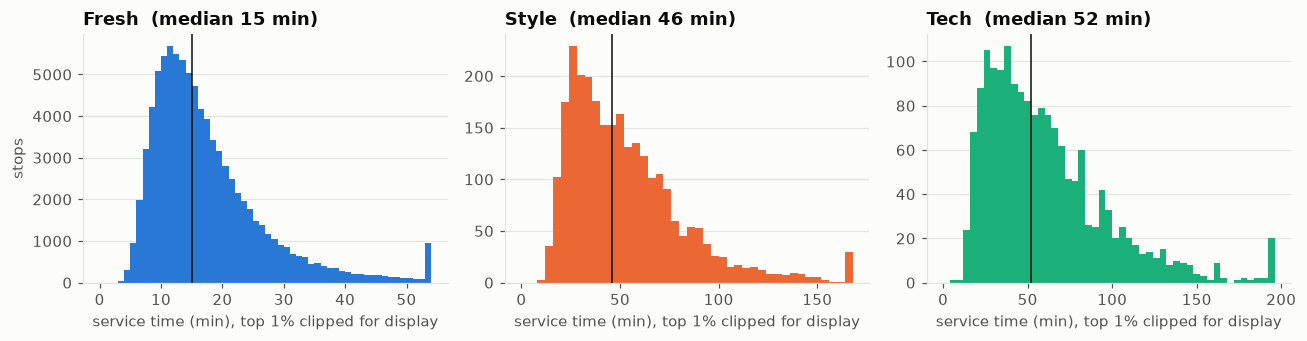

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
for ax, brand, color in zip(axes, ["Fresh", "Style", "Tech"], SERIES):
    s = stops.loc[train & (stops.brand == brand), "service_min"]
    cap = s.quantile(0.99)
    width = 1 if brand == "Fresh" else 4  # times are whole minutes, so bins must be too
    ax.hist(s.clip(upper=cap), bins=np.arange(0, cap + width, width), color=color)
    ax.axvline(s.median(), color="#0b0b0b", linewidth=1)
    ax.set_title(f"{brand}  (median {s.median():.0f} min)")
    ax.set_xlabel("service time (min), top 1% clipped for display")
axes[0].set_ylabel("stops")
plt.tight_layout()
plt.show()

In [43]:
stops.loc[train].pivot_table(index="brand", columns="dock_type", values="service_min", aggfunc="median")

dock_type,mall_bay,rear_dock,street
brand,,,
Fresh,NaN,15.0,14.0
Style,61.0,30.0,45.0
Tech,74.0,35.0,67.0


Service time differs a lot by brand and by how goods come off the truck: rear docks are quickest, and mall bays are slowest for Style and Tech. The distributions are right-skewed, with a long tail of slow stops. Those are kept, as explained in Part 3.

### 4.3 Late label

Waypoint defines late as arriving after `window_close_time`. Late deliveries are still made, so this label is about arrival only, not about whether the order was delivered.

```
late = 1 if arrival_time > window_close_time else 0
```

Arriving exactly at closing time counts as on time, because the operating rules say "after".

In [44]:
stops["late"] = (stops.arrival_time_min > stops.window_close_time_min).astype("Int8").where(train)
stops["late_by_min"] = (stops.arrival_time_min - stops.window_close_time_min).clip(lower=0).where(train)

pd.Series({
    "late rate": stops.loc[train, "late"].mean().round(3),
    "arrivals exactly at closing time (counted on time)": int((stops.arrival_time_min == stops.window_close_time_min)[train].sum()),
    "median minutes late, when late": stops.loc[train & (stops.late == 1), "late_by_min"].median(),
})

late rate                                               0.196
arrivals exactly at closing time (counted on time)    279.000
median minutes late, when late                         48.000
dtype: float64

In [45]:
stops.loc[train].groupby(["brand", "depot"]).late.agg(late_rate="mean", stops="size").round(3)

late_rate  stops
brand depot                       
Fresh Kandy           0.202  34039
      Peliyagoda      0.205  53418
Style Kandy           0.035    977
      Peliyagoda      0.066   1756
Tech  Kandy           0.064    593
      Peliyagoda      0.004   1111

About one stop in five arrives late, mostly Fresh, where the window closes around 8 AM and routes are long. Classes are imbalanced but not extreme, so a plain probability model with good calibration is appropriate. No resampling is needed.

### 4.4 Proving the labels

A label is only as good as the times it is built from, so we check the three facts it relies on, plus the basic sanity of the result.

In [46]:
t = stops[train].sort_values(["route_id", "seq"])
next_depart = legs[legs.split == "train"].sort_values(["route_id", "seq"]).groupby("route_id").actual_depart_time_min.shift(-1).to_numpy()
arrival_gap = t.arrival_time_min - (t.actual_depart_time_min + t.actual_travel_duration_min)

proofs = ck.report([
    ck.check("every dispatched train order has exactly one leg", t.leg_id.isna().sum(), len(t)),
    ck.check("leave time equals the next leg's departure", ((next_depart == next_depart) & (next_depart != t.leave_outlet_time_min.to_numpy())).sum(), len(t),
             "so leave_outlet_time is a real event, not an estimate"),
    ck.check("arrival = departure + travel, within 1 minute rounding", (arrival_gap.abs() > 1).sum(), len(t)),
    ck.check("service time is positive", (t.service_min <= 0).sum(), len(t)),
    ck.check("wait is never negative", (t.wait_min < 0).sum(), len(t)),
    ck.check("every train stop has both labels", t[["service_min", "late"]].isna().any(axis=1).sum(), len(t)),
    ck.check("test stops have no labels (no leakage of actuals)", stops.loc[~train, ["service_min", "late"]].notna().any(axis=1).sum(), (~train).sum()),
])
proofs

,check,passed,failing_rows,total_rows,note
0,every dispatched train order has exactly one leg,True,0,91894,
1,leave time equals the next leg's departure,True,0,91894,"so leave_outlet_time is a real event, not an estimate"
2,"arrival = departure + travel, within 1 minute rounding",True,0,91894,
3,service time is positive,True,0,91894,
4,wait is never negative,True,0,91894,
5,every train stop has both labels,True,0,91894,
6,test stops have no labels (no leakage of actuals),True,0,5014,


#### How good is today's planning standard?

Waypoint plans with a fixed allowance per brand and dock type (`service_allowance.csv`). Comparing it with the label gives the baseline our service-time model has to beat.

In [47]:
with_allowance = stops[train].merge(allowance, on=["brand", "dock_type"], how="left", validate="many_to_one")
err = with_allowance.service_min - with_allowance.service_allowance_min

baseline = with_allowance.assign(err=err).groupby("brand").err.agg(
    mae=lambda e: e.abs().mean(), bias="mean", share_over_by_10_min=lambda e: (e > 10).mean()
)
baseline.loc["all"] = [err.abs().mean(), err.mean(), (err > 10).mean()]
baseline.round(2)

,mae,bias,share_over_by_10_min
brand,,,
Fresh,6.73,1.83,0.14
Style,19.62,3.79,0.30
Tech,24.89,11.28,0.40
all,7.45,2.06,0.15


The allowance table is off by several minutes per stop on average and is badly off for Tech, where it also runs too low. This is the "before" number for Task 1.

### 4.5 Weekly demand table for Task 2A

The table follows three rules:
1. Count every order once, including deferred and never-dispatched (`not_run`) orders.
2. Assign each order to the week of its requested order date, not its dispatch date.
3. Group by `iso_year` and `iso_week` from `calendar.csv`.

Training orders cover ISO weeks up to 2026 week 7. The Task 1 test inputs cover weeks 8 to 13 and are the natural source for that gap. Task 2A then forecasts weeks 14 to 23.

In [48]:
orders_wk = orders.merge(calendar[["date", "iso_year", "iso_week"]], left_on="order_date", right_on="date", how="left", validate="many_to_one")
orders_wk["chilled_volume_m3"] = orders_wk.order_volume_m3.where(orders_wk.temp_requirement == "chilled", 0.0)

weekly = (
    orders_wk.groupby(["depot", "brand", "iso_year", "iso_week"])
    .agg(
        total_volume_m3=("order_volume_m3", "sum"),
        chilled_volume_m3=("chilled_volume_m3", "sum"),
        orders=("delivery_id", "size"),
        source=("split", lambda s: "test inputs" if (s == "test").all() else "train"),
    )
    .reset_index()
)
weekly.assign(year_week=weekly.iso_year.astype(str) + "-W" + weekly.iso_week.astype(str).str.zfill(2)).groupby("source").agg(
    series_weeks=("year_week", "size"), first_week=("year_week", "min"), last_week=("year_week", "max")
)

,series_weeks,first_week,last_week
source,,,
test inputs,36,2026-W08,2026-W13
train,666,2024-W01,2026-W07


#### Adjusting the test weeks for missing `not_run` orders

Rule 1 says to count orders that were never dispatched, but the test inputs contain none (Part 3). Leaving this alone would make weeks 8 to 13 look slightly lower than they really were, right where the forecast starts.

We estimate the missing volume from training. For each depot, brand and temperature, we take the volume of `not_run` orders as a share of all other orders, then scale up the test weeks by that share. The adjustment is small, so the raw totals are kept next to the adjusted ones.

In [49]:
hist = orders_wk[orders_wk.split == "train"]
key = ["depot", "brand", "temp_requirement"]
not_run_vol = hist[hist.dispatch_status == "not_run"].groupby(key).order_volume_m3.sum()
other_vol = hist[hist.dispatch_status != "not_run"].groupby(key).order_volume_m3.sum()
uplift = (not_run_vol / other_vol).reindex(other_vol.index, fill_value=0.0).rename("not_run_uplift")

uplift.unstack("temp_requirement").fillna(0).round(4)

temp_requirement  ambient  chilled
depot      brand                  
Kandy      Fresh   0.0003   0.0000
           Style   0.0136   0.0000
           Tech    0.0265   0.0000
Peliyagoda Fresh   0.0000   0.0168
           Style   0.0000   0.0000
           Tech    0.0000   0.0000

`not_run` orders are not spread evenly. Almost all are Peliyagoda chilled Fresh orders, which fits a shortage of refrigerated capacity there, plus a handful of large Style and Tech orders at Kandy. Using each group's long-run share gives the expected missing volume for a typical week, which is the best estimate we have without the actual orders.

In [50]:
test_wk = orders_wk[orders_wk.split == "test"].merge(uplift.reset_index(), on=key, how="left")
test_wk["extra_m3"] = test_wk.order_volume_m3 * test_wk.not_run_uplift
extra = test_wk.groupby(["depot", "brand", "iso_year", "iso_week"]).agg(
    extra_total_m3=("extra_m3", "sum"),
    extra_chilled_m3=("extra_m3", lambda s: s[test_wk.loc[s.index, "temp_requirement"] == "chilled"].sum()),
)

weekly = weekly.merge(extra.reset_index(), on=["depot", "brand", "iso_year", "iso_week"], how="left").fillna({"extra_total_m3": 0.0, "extra_chilled_m3": 0.0})
weekly["total_volume_m3_adj"] = weekly.total_volume_m3 + weekly.extra_total_m3
weekly["chilled_volume_m3_adj"] = weekly.chilled_volume_m3 + weekly.extra_chilled_m3
weekly = weekly.drop(columns=["extra_total_m3", "extra_chilled_m3"])

weekly[weekly.source == "test inputs"].groupby(["depot", "brand"])[["total_volume_m3", "total_volume_m3_adj"]].sum().assign(
    added_pct=lambda d: (d.total_volume_m3_adj / d.total_volume_m3 - 1) * 100
).round(2)

total_volume_m3  total_volume_m3_adj  added_pct
depot      brand                                                 
Kandy      Fresh          3140.23              3140.82       0.02
           Style           505.81               512.67       1.36
           Tech            118.22               121.35       2.65
Peliyagoda Fresh          5926.43              5962.60       0.61
           Style           898.31               898.31       0.00
           Tech            178.33               178.33       0.00

Checks on the finished table: every series has every week with no gaps, Style and Tech have no chilled volume (neither brand carries chilled goods), and the totals reconcile with the raw orders.

In [51]:
weeks_in_calendar = calendar[calendar.date <= orders.order_date.max()].drop_duplicates(["iso_year", "iso_week"]).shape[0]
per_series = weekly.groupby(["depot", "brand"]).size()

ck.report([
    ck.check("every depot and brand has every week", (per_series != weeks_in_calendar).sum(), len(per_series),
             f"{weeks_in_calendar} weeks per series"),
    ck.check("Style and Tech have zero chilled volume", (weekly.loc[weekly.brand != "Fresh", "chilled_volume_m3_adj"] != 0).sum(), (weekly.brand != "Fresh").sum()),
    ck.check("chilled never exceeds total", (weekly.chilled_volume_m3_adj > weekly.total_volume_m3_adj + 1e-9).sum(), len(weekly)),
    ck.check("raw weekly totals add up to the raw orders", int(abs(weekly.total_volume_m3.sum() - orders.order_volume_m3.sum()) > 1e-6), 1),
    ck.check("each order counted once", int(weekly.orders.sum() != len(orders)), 1),
])

,check,passed,failing_rows,total_rows,note
0,every depot and brand has every week,True,0,6,117 weeks per series
1,Style and Tech have zero chilled volume,True,0,468,
2,chilled never exceeds total,True,0,702,
3,raw weekly totals add up to the raw orders,True,0,1,
4,each order counted once,True,0,1,


In [52]:
weekly.tail(6)

,depot,brand,iso_year,iso_week,total_volume_m3,chilled_volume_m3,orders,source,total_volume_m3_adj,chilled_volume_m3_adj
696,Peliyagoda,Tech,2026,8,23.253,0.0,9,test inputs,23.253,0.0
697,Peliyagoda,Tech,2026,9,40.091,0.0,11,test inputs,40.091,0.0
698,Peliyagoda,Tech,2026,10,22.986,0.0,7,test inputs,22.986,0.0
699,Peliyagoda,Tech,2026,11,21.290,0.0,7,test inputs,21.290,0.0
700,Peliyagoda,Tech,2026,12,33.188,0.0,11,test inputs,33.188,0.0
701,Peliyagoda,Tech,2026,13,37.519,0.0,11,test inputs,37.519,0.0


### 4.6 Save and summarise

In [53]:
save_processed(stops, "stops")
save_processed(weekly, "weekly_demand")

pd.DataFrame({
    "rows": [len(stops), len(weekly)],
    "labelled rows": [int(stops.service_min.notna().sum()), len(weekly)],
}, index=["stops", "weekly_demand"])

,rows,labelled rows
stops,96908,91894
weekly_demand,702,702


**Label card**

| Label | Definition | Rows | Key numbers |
|---|---|---|---|
| `service_min` | leave time minus the later of arrival and window opening | every dispatched train order | Fresh median about 15 min, Style and Tech about 45 to 55 |
| `late` | arrival strictly after window close | every dispatched train order | about 20% late overall |
| `total_volume_m3_adj` | weekly order volume by order date and ISO week, test weeks adjusted for missing `not_run` orders | 6 series x every week | target for Task 2A |
| `chilled_volume_m3_adj` | chilled part of the above, 0 for Style and Tech | same | target for Task 2A |

**Decisions made here, and why**
- Waiting for the window to open is excluded from service time, because the operating rules say early arrivals wait.
- Deferred orders keep their labels, because they were really delivered (next day) and have real times.
- Long stops are kept, because they are real and the model must learn that delays happen.
- Test weeks are scaled up slightly for `not_run` orders, because they are real demand that the test inputs leave out.

Next: Part 5 builds features and checks that each one would be known at the 4 PM order cutoff.

## Part 5. Feature engineering

**Purpose:** turn each planned stop into the inputs the Task 1 models will use, and prove that every input is something a planner actually has when the plan is drafted.

**Inputs:** `stops.parquet` from Part 4 and the clean reference tables from Part 3.

**Outputs:**
- `data/processed/task1_features.parquet`: one row per dispatched order (train and test) with all features and, for train, the two labels
- `reports/feature_audit.csv`: every feature, where it comes from and why it is available in time

**The one rule:** Waypoint drafts tomorrow's routes at the 4 PM cutoff. A feature is allowed only if it is known at that moment. That rules out anything measured on the delivery day itself, and even the previous day's results, because those routes may still be on the road at 4 PM.

The feature code lives in `src/xora/features.py` so that Parts 6, 9 and 11 build exactly the same inputs. This part calls it one group at a time and shows what each group adds.

In [54]:
stops = load_processed("stops")
outlets = load_processed("outlets")
vehicles = load_processed("vehicles")
allowance = load_processed("service_allowance")
calendar = load_processed("calendar")
road = load_processed("road_conditions")
traffic = load_processed("traffic_speed")

train = stops.split == "train"
stops.groupby("split").agg(stops=("delivery_id", "size"), first_day=("date", "min"), last_day=("date", "max"))

,stops,first_day,last_day
split,,,
test,5014,2026-02-16,2026-03-28
train,91894,2024-01-01,2026-02-14


### 5.1 Train and test stops

The test stops start two days after training ends, and they carry only planned times. The features below are built the same way for both, so the model never sees anything at training time that it would not have for the test.

### 5.2 Order and vehicle features

What is being delivered, where it goes and what it travels on. All of this is on the order and the drafted plan.

- size of the order: units, weight, volume, and weight per unit (bulky Tech items take longer to move)
- outlet: brand, district, dock type, parking constraint, whether it is a mall with a delivery slot
- vehicle: type, refrigeration and capacity
- `was_deferred`: the order was pushed from the previous day, which the planner knows
- `allowance_min`: today's published allowance for this brand and dock type, the baseline the model has to beat

In [55]:
order_f = fe.order_features(stops, outlets, vehicles, allowance)
print(order_f.shape)
order_f.head(3).T

(96908, 19)


,0,1,2
brand,Fresh,Fresh,Fresh
depot,Peliyagoda,Peliyagoda,Peliyagoda
district,Colombo,Colombo,Colombo
temp_requirement,ambient,ambient,ambient
dock_type,street,street,street
parking_constraint,van_only,van_only,van_only
vehicle_type,van,van,van
vehicle_temp,ambient,ambient,ambient
outlet_id,OUT001,OUT002,OUT003
order_units,8,15,15


### 5.3 Route position features

Part 2 showed that lateness builds up along the route. These features describe where a stop sits in its drafted route and how much room the plan leaves.

- position: stop number, stops before and after, whether the truck comes straight from the same outlet
- load: route volume and weight, and the volume delivered before this stop
- distance and planned travel, for this leg and so far
- timing: planned start, planned arrival, minutes into the route
- window: length, planned slack to closing time, minutes the plan arrives before opening, and the tightest slack still ahead on the route

In [56]:
route_f = fe.route_features(stops)
print(route_f.shape)
route_f.loc[stops.route_id == stops.route_id.iloc[0]].T

(96908, 21)


,0,1,2
seq,0.000,2.000,1.000
is_first_stop,1.000,0.000,0.000
route_n_stops,3.000,3.000,3.000
stops_after,2.000,0.000,1.000
same_outlet_as_previous,0.000,0.000,0.000
route_volume_m3,1.518,1.518,1.518
route_weight_kg,263.300,263.300,263.300
volume_before_m3,0.000,0.954,0.402
route_distance_km,22.100,22.100,22.100
distance_so_far_km,13.700,22.100,18.300


**A check on the plan itself.** The time the plan allows at each stop (the next leg's planned departure minus this arrival) is exactly the published allowance at every stop that has a next leg. So the plan carries no hidden knowledge about service time, and `allowance_min` already captures it. We keep one copy.

In [57]:
s = stops.sort_values(["route_id", "seq"])
planned_stop = s.groupby("route_id").planned_depart_time_min.shift(-1) - s.planned_arrival_time_min_x
has_next = planned_stop.notna()
pd.Series({
    "stops with a next leg": int(has_next.sum()),
    "planned stop time equals the allowance": float((planned_stop[has_next] == order_f.loc[planned_stop[has_next].index, "allowance_min"]).mean()),
})

stops with a next leg                     70329.0
planned stop time equals the allowance        1.0
dtype: float64

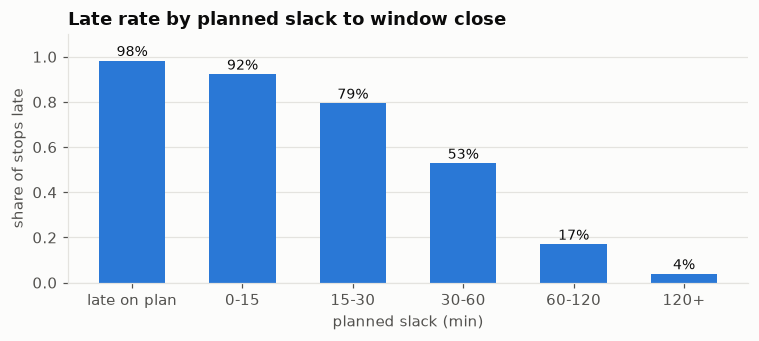

In [58]:
bands = pd.cut(route_f.planned_slack_min, [-np.inf, 0, 15, 30, 60, 120, np.inf],
               labels=["late on plan", "0-15", "15-30", "30-60", "60-120", "120+"])
late_by_band = stops.loc[train].groupby(bands[train], observed=True).late.mean()

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(late_by_band.index.astype(str), late_by_band.values, color=SERIES[0], width=0.6)
for i, v in enumerate(late_by_band.values):
    ax.text(i, v + 0.02, f"{v:.0%}", ha="center", color=INK, fontsize=9)
ax.set_ylim(0, 1.1)
ax.set_title("Late rate by planned slack to window close")
ax.set_xlabel("planned slack (min)")
ax.set_ylabel("share of stops late")
plt.tight_layout()
plt.show()

Planned slack is the single clearest signal for lateness, but even stops with one to two hours of slack are sometimes late. The plan is optimistic, so slack on paper is not slack on the road. Section 5.6 corrects it with history.

### 5.4 Calendar and road conditions

- **Calendar:** day of week, month, payday, public holiday, festival day, festival ramp, monsoon, days until the next festival and a trend counter. The calendar is published well ahead.
- **Road advisory:** `disruption_index` for the district and day. The file covers the test dates, so it behaves like a published road and weather advisory. This is the one borderline input, so Part 6 tests the models with and without it.
- **Typical traffic:** `speed_index` for the district at the planned arrival hour, in or out of monsoon. This is a long-run profile, not a live reading.

Sunday never appears in the data, so a weekend flag would be constant and is left out.

In [59]:
cal_f = fe.calendar_features(stops, calendar)
cond_f = fe.condition_features(stops, route_f, road, traffic)
pd.concat([cal_f, cond_f], axis=1).describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
dow,96908.0,2.52,1.69,0.0,1.0,3.0,4.0,5.0
month,96908.0,6.02,3.57,1.0,3.0,6.0,9.0,12.0
is_payday,96908.0,0.07,0.26,0.0,0.0,0.0,0.0,1.0
is_holiday,96908.0,0.02,0.12,0.0,0.0,0.0,0.0,1.0
monsoon,96908.0,0.48,0.50,0.0,0.0,0.0,1.0,1.0
festival_ramp,96908.0,0.10,0.24,0.0,0.0,0.0,0.0,1.0
is_festival_day,96908.0,0.02,0.12,0.0,0.0,0.0,0.0,1.0
days_to_festival,96908.0,30.81,19.72,0.0,13.0,28.0,49.0,60.0
trend_days,96908.0,408.40,236.82,0.0,204.0,407.0,613.0,817.0
disruption_index,96908.0,92.67,12.82,41.0,91.0,99.0,100.0,100.0


### 5.5 History features

How an outlet, a vehicle or a district has behaved before is strong evidence, but it is also the easiest place to leak the answer. Three rules keep it honest:

1. **Only finished days count.** A result from day D becomes usable on day D + 2. Plans for D are drafted on D-1, when D-1's own routes may still be running.
2. **Small samples lean on their group.** An outlet's average is blended with its brand and dock type average, weighted by how many past stops it has (smoothing of 20 stops). A new outlet starts at the group average instead of an unreliable guess.
3. **The same code serves train and test.** For a test day, the newest usable history is simply the end of training, which is what a planner would have.

The history features:
- `outlet_hist_service_mean`, `outlet_hist_late_rate`, `outlet_hist_stops`
- `group_hist_service_mean` for the brand and dock type
- `district_hist_travel_ratio`: actual over planned travel time, by district and monsoon
- `vehicle_hist_depart_delay`: how late this vehicle usually leaves the depot

In [60]:
hist_f = fe.history_features(stops)
hist_f.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
group_hist_service_mean,96627.0,18.41,8.66,11.50,16.41,16.86,17.13,88.06
outlet_hist_stops,96908.0,548.05,340.97,0.00,242.00,545.00,849.00,1100.00
outlet_hist_service_mean,96627.0,18.41,10.46,7.96,12.72,15.60,21.05,102.52
outlet_hist_late_rate,96627.0,0.19,0.18,0.00,0.04,0.12,0.29,0.78
district_hist_travel_ratio,96361.0,1.71,0.33,1.05,1.42,1.66,1.92,2.70
vehicle_hist_depart_delay,96636.0,7.82,0.36,6.14,7.60,7.78,8.01,10.79


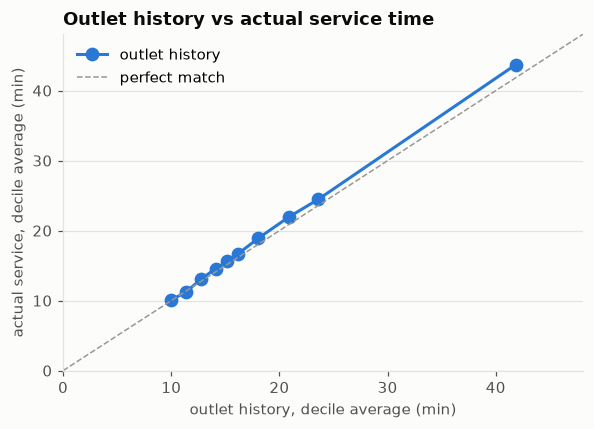

In [61]:
x = hist_f.loc[train, "outlet_hist_service_mean"]
y = stops.loc[train, "service_min"]
deciles = pd.qcut(x, 10, duplicates="drop")
binned = pd.DataFrame({"predicted": x, "actual": y}).groupby(deciles, observed=True).mean()

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.plot(binned.predicted, binned.actual, marker="o", markersize=8, color=SERIES[0], label="outlet history")
lim = [0, binned.max().max() * 1.1]
ax.plot(lim, lim, color="#9a9893", linewidth=1, linestyle="--", label="perfect match")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_title("Outlet history vs actual service time")
ax.set_xlabel("outlet history, decile average (min)")
ax.set_ylabel("actual service, decile average (min)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

On its own, an outlet's own past is already a well calibrated guess of its service time: the decile points sit close to the diagonal, slightly above it because service times creep up over time. The model's job is to explain the rest (order size, festivals, paydays, monsoon).

### 5.6 All features together

`build_task1_features` runs the five groups above and adds four combinations of the plan with history:

- `load_share_volume` and `load_share_weight`: how full the vehicle is
- `expected_travel_min`: planned travel scaled by how much slower that district usually runs
- `slack_after_history_min`: planned slack minus the extra travel history predicts so far on the route, minus the vehicle's usual late departure. This is a realistic version of slack.

In [62]:
feats = fe.build_task1_features(stops, outlets, vehicles, allowance, calendar, road, traffic)
print(feats.shape)
blanks = feats.isna().sum()
blanks[blanks > 0].rename("blank rows").to_frame()

(96908, 61)


,blank rows
group_hist_service_mean,281
outlet_hist_service_mean,281
outlet_hist_late_rate,281
district_hist_travel_ratio,547
vehicle_hist_depart_delay,272
expected_travel_min,547
slack_after_history_min,547


The only blanks are history features in the first days of 2024, before any day has finished. LightGBM handles missing values natively, so these rows stay in.

In [63]:
num = feats.select_dtypes("number")
signal = pd.DataFrame({
    "service_min": num[train].corrwith(stops.loc[train, "service_min"], method="spearman"),
    "late": num[train].corrwith(stops.loc[train, "late"].astype(float), method="spearman"),
}).round(3)
signal.reindex(signal.abs().max(axis=1).sort_values(ascending=False).index).head(15)

,service_min,late
outlet_hist_service_mean,0.672,0.052
slack_after_history_min,-0.038,-0.570
order_volume_m3,0.523,0.041
order_weight_kg,0.511,0.044
planned_slack_min,-0.030,-0.494
outlet_hist_late_rate,0.003,0.447
planned_arrival_min,0.213,0.437
planned_hour,0.215,0.417
speed_index,-0.105,-0.401
minutes_into_route,0.001,0.388


Rank correlations on the training stops are a quick, honest first look (models will find interactions these miss):
- Service time is driven by order size and the outlet's own history.
- Lateness is driven by slack, and the history-corrected slack ranks lateness better than slack on paper. This is the simulation idea in miniature: correct the plan with how the road actually behaves.

### 5.7 Proof that no feature peeks at the answer

The rules above are only claims until tested. For a set of delivery days D, we hide every actual time and label from D-1 onward, rebuild all features, and check that the features for day D do not change at all. As a control, hiding from D-2 onward should change them, which shows the test is sensitive enough to catch a leak.

In [64]:
def hide_actuals_from(df, first_hidden_day):
    df = df.copy()
    df.loc[df["date"] >= first_hidden_day, fe.ACTUAL_COLS] = np.nan
    return df

def rebuild(df):
    return fe.build_task1_features(df, outlets, vehicles, allowance, calendar, road, traffic)

test_days = pd.to_datetime(["2024-04-11", "2024-10-16", "2025-04-10", "2025-10-15", "2026-02-14"])
rows = []
for day in test_days:
    on_day = stops["date"] == day
    hidden_d1 = rebuild(hide_actuals_from(stops, day - pd.Timedelta(days=1)))
    hidden_d2 = rebuild(hide_actuals_from(stops, day - pd.Timedelta(days=2)))
    rows.append({
        "delivery day": day.date(),
        "stops": int(on_day.sum()),
        "unchanged with D-1 onward hidden": feats.loc[on_day].equals(hidden_d1.loc[on_day]),
        "changed with D-2 onward hidden": not feats.loc[on_day].equals(hidden_d2.loc[on_day]),
    })
leak_test = pd.DataFrame(rows)
assert leak_test.iloc[:, 2:].all().all()
leak_test

,delivery day,stops,unchanged with D-1 onward hidden,changed with D-2 onward hidden
0,2024-04-11,146,True,True
1,2024-10-16,148,True,True
2,2025-04-10,145,True,True
3,2025-10-15,154,True,True
4,2026-02-14,140,True,True


Every feature for a delivery day is identical whether or not the delivery day and the day before it happened. The control confirms the check would catch a one-day leak. The test days include festival and monsoon peaks and the last training day.

### 5.8 Feature availability audit

One row per feature: where it comes from and why a planner has it at 4 PM on the day before delivery. This table also goes into the preprocessing document.

In [65]:
GROUPS = {
    "Order and vehicle": (order_f.columns, "orders, outlets, vehicles, allowance table", "On the confirmed order and the drafted plan"),
    "Route position": (route_f.columns, "drafted route legs", "Planned times and distances of the drafted route"),
    "Calendar": (cal_f.columns, "calendar", "Published calendar"),
    "Road and traffic": (cond_f.columns, "road conditions, traffic profile", "Published advisory and long-run traffic profile"),
    "History": (hist_f.columns, "past finished stops", "Only days finished at least 2 days before delivery"),
}
audit = pd.DataFrame(
    [{"feature": c, "group": g, "source": src, "available at 4 PM": "yes", "why": why}
     for g, (cols, src, why) in GROUPS.items() for c in cols]
)
combined = [c for c in feats.columns if c not in set(audit.feature)]
audit = pd.concat([audit, pd.DataFrame({
    "feature": combined, "group": "Plan combined with history", "source": "features above",
    "available at 4 PM": "yes", "why": "Built only from the features above",
})], ignore_index=True)
audit.loc[audit.feature == "disruption_index", ["available at 4 PM", "why"]] = [
    "borderline", "Treated as a published advisory; models are tested with and without it"]

assert set(audit.feature) == set(feats.columns) and audit.feature.is_unique
REPORTS.mkdir(parents=True, exist_ok=True)
audit.to_csv(REPORTS / "feature_audit.csv", index=False)
print(f"{len(audit)} features audited")
audit.groupby(["group", "available at 4 PM"]).size().rename("features").to_frame()

61 features audited


features
group                      available at 4 PM          
Calendar                   yes                       9
History                    yes                       6
Order and vehicle          yes                      19
Plan combined with history yes                       4
Road and traffic           borderline                1
                           yes                       1
Route position             yes                      21

### 5.9 Save

The saved table keeps the keys needed to join predictions back (`delivery_id`, route and stop), the split, and the two labels next to the features.

In [66]:
KEYS = ["delivery_id", "split", "date", "route_id", "seq_in_route"]
LABELS = ["service_min", "late"]
task1 = pd.concat([stops[KEYS], feats, stops[LABELS]], axis=1)

assert task1.delivery_id.is_unique
assert task1.loc[task1.split == "test", LABELS].isna().all().all()
assert task1.loc[task1.split == "train", LABELS].notna().all().all()

save_processed(task1, "task1_features")
task1.groupby("split").size().rename("rows").to_frame()

,rows
split,
test,5014
train,91894


### Part 5 summary

- **61 features** in six groups, all available at the 4 PM cutoff. One, the road advisory, is flagged as borderline and will be tested both ways.
- **The plan's stop time is just the allowance table**, so the plan holds no hidden service-time information.
- **History is leak-proof by test**, not just by design: hiding the delivery day and the day before leaves every feature unchanged.
- **Slack corrected by history** ranks lateness better than slack on paper, which supports the route simulation planned for Part 6.

Next, Part 6 trains the Task 1 models on `task1_features.parquet`.